In [56]:
import pandas as pd
import numpy as np

In [57]:
data = pd.read_csv("03_Clustering_Marketing.csv")

data.head()


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [58]:
print("Пропущенные значения:\n", data.isnull().sum())

Пропущенные значения:
 gradyear              0
gender             1337
age                2496
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64


In [83]:
data = data.dropna()

df_new = pd.DataFrame()
# Группы столбцов
sports_cols = ['basketball', 'football', 'soccer', 'softball', 'volleyball', 'swimming', 'cheerleading', 'baseball', 'tennis', 'sports']
appearance_cols = ['cute', 'sex', 'sexy', 'hot', 'kissed', 'blonde', 'hair']
music_cols = ['dance', 'band', 'marching', 'music', 'rock']
religion_cols = ['god', 'church', 'jesus', 'bible']
fashion_cols = ['dress', 'mall', 'shopping', 'clothes', 'hollister', 'abercrombie']
dark_cols = ['die', 'death', 'drunk', 'drugs']

# Суммируем значения по темам
df_new['sports_sum'] = data[sports_cols].sum(axis=1)
df_new['appearance_sum'] = data[appearance_cols].sum(axis=1)
df_new['music_sum'] = data[music_cols].sum(axis=1)
df_new['religion_sum'] = data[religion_cols].sum(axis=1)
df_new['fashion_sum'] = data[fashion_cols].sum(axis=1)
df_new['dark_sum'] = data[dark_cols].sum(axis=1)

# #  базовые данные
# df_new['gradyear'] = data['gradyear']
# df_new['gender'] = data['gender']
# df_new['age'] = data['age']
# # Преобразуем значения к числам: если не получилось — будет NaN
# df_new['age'] = pd.to_numeric(df_new['age'], errors='coerce')

# # Удаляем строки с NaN в age (т.е. где было нечисловое значение)
# df_new = df_new.dropna(subset=['age'])
# df_new['age'] = df_new['age'].astype(float)
# df_new['NumberOffriends'] = data['NumberOffriends']

# df_new['gender'] = data['gender'].map({'M': 1, 'F': 0}).astype(int)

df_new

,sports_sum,appearance_sum,music_sum,religion_sum,fashion_sum,dark_sum
1,2,0,0,1,0,1
2,1,7,3,1,1,2
4,4,13,1,2,3,0
5,5,0,3,0,0,0
6,0,1,0,1,1,0
...,...,...,...,...,...,...
14995,0,1,1,1,2,1
14996,1,0,1,2,0,1
14997,1,1,0,0,0,0
14998,0,0,1,0,0,0


C:\Users\krasn\AppData\Local\Temp\ipykernel_152960\1844836049.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
C:\Users\krasn\AppData\Local\Temp\ipykernel_152960\1844836049.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
C:\Users\krasn\AppData\Local\Temp\ipykernel_152960\1844836049.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
C:\Users\krasn\AppData\Local\Temp\ipykernel_152960\1844836049

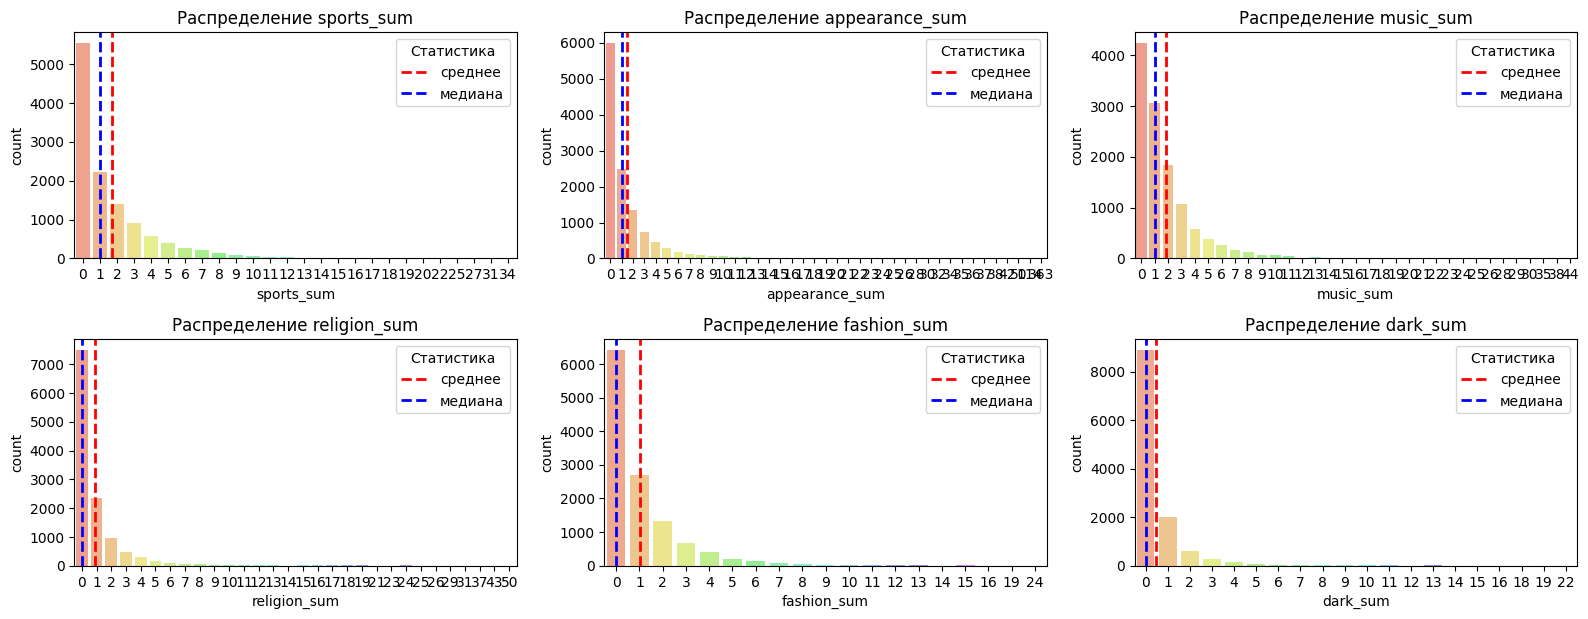

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16, 12))
for i, col in enumerate(df_new.columns):
    plt.subplot(4, 3, i+1)
    if df_new[col].nunique() < 100:
        sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
    else:
        sns.kdeplot(df_new[col], fill=True, alpha=0.5)
    plt.title(f'Распределение {col}')
    
    plt.axvline(df_new[col].mean(), color='red', linestyle='dashed', linewidth=2, label='среднее')
    plt.axvline(df_new[col].median(), color='blue', linestyle='dashed', linewidth=2, label='медиана')
    plt.legend(loc='upper right', title='Статистика')
plt.tight_layout()
plt.show()

In [73]:
df_new['gradyear'].unique()
df_new['NumberOffriends'].describe()
df_new['age'].describe()

count    11772.000000
mean        17.948992
std          7.501275
min          4.309000
25%         16.330500
50%         17.298000
75%         18.270000
max        106.927000
Name: age, dtype: float64

In [100]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df_new.select_dtypes(include='number').columns

scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_new[numeric_cols]), columns=numeric_cols, index=df_new.index)
df_norm

,sports_sum,appearance_sum,music_sum,religion_sum,fashion_sum,dark_sum
1,0.058824,0.000000,0.000000,0.02,0.000000,0.045455
2,0.029412,0.019284,0.068182,0.02,0.041667,0.090909
4,0.117647,0.035813,0.022727,0.04,0.125000,0.000000
5,0.147059,0.000000,0.068182,0.00,0.000000,0.000000
6,0.000000,0.002755,0.000000,0.02,0.041667,0.000000
...,...,...,...,...,...,...
14995,0.000000,0.002755,0.022727,0.02,0.083333,0.045455
14996,0.029412,0.000000,0.022727,0.04,0.000000,0.045455
14997,0.029412,0.002755,0.000000,0.00,0.000000,0.000000
14998,0.000000,0.000000,0.022727,0.00,0.000000,0.000000


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_new[numeric_cols]), columns=numeric_cols, index=df_new.index)
df_norm

,sports_sum,appearance_sum,music_sum,religion_sum,fashion_sum,dark_sum
1,0.121969,-0.344359,-0.693275,0.061218,-0.617919,0.457849
2,-0.265053,1.254330,0.448051,0.061218,-0.026661,1.322158
4,0.896011,2.624634,-0.312833,0.564421,1.155854,-0.406459
5,1.283032,-0.344359,0.448051,-0.441984,-0.617919,-0.406459
6,-0.652074,-0.115975,-0.693275,0.061218,-0.026661,-0.406459
...,...,...,...,...,...,...
14995,-0.652074,-0.115975,-0.312833,0.061218,0.564596,0.457849
14996,-0.265053,-0.344359,-0.312833,0.564421,-0.617919,0.457849
14997,-0.265053,-0.115975,-0.693275,-0.441984,-0.617919,-0.406459
14998,-0.652074,-0.344359,-0.312833,-0.441984,-0.617919,-0.406459


In [101]:
from sklearn.metrics import pairwise_distances

df_norm = df_norm.reset_index(drop=True)
# Считаем расстояния между объектами (строками)
distance_matrix = pairwise_distances(df_norm, metric='cosine')

# Оформляем результат в DataFrame
df_distance = pd.DataFrame(distance_matrix, index=df_norm.index, columns=df_norm.index)

print(df_distance.head())

      0             1             2         3             4         5      \
0  0.000000  3.625691e-01  4.468005e-01  0.306770  8.877761e-01  0.653214   
1  0.362569  1.110223e-16  4.939038e-01  0.566185  6.294902e-01  0.449105   
2  0.446800  4.939038e-01  2.220446e-16  0.358513  2.724229e-01  0.605386   
3  0.306770  5.661849e-01  3.585132e-01  0.000000  1.000000e+00  0.479537   
4  0.887776  6.294902e-01  2.724229e-01  1.000000  2.220446e-16  0.720337   

      6         7         8      9      ...     12032     12033     12034  \
0  1.000000  1.000000  0.161168    1.0  ...  0.803656  0.498039  1.000000   
1  0.451433  0.673504  0.672664    1.0  ...  0.412688  0.211807  0.673504   
2  0.851773  0.310485  0.357356    1.0  ...  0.711939  0.624817  0.310485   
3  0.582430  1.000000  0.101590    1.0  ...  0.403647  1.000000  1.000000   
4  0.992840  0.100074  1.000000    1.0  ...  0.938696  0.527358  0.100074   

      12035     12036     12037     12038     12039     12040     12041  


In [88]:
import numpy as np
import heapq
from tqdm import tqdm


# df_distance — DataFrame, индексы от 1 до n
n = len(df_distance)
dist_matrix = df_distance.values  # numpy array для быстрого доступа

visited = np.zeros(n, dtype=bool)
min_edge = [np.inf] * n  # минимальное расстояние до остовного дерева
from_node = [-1] * n     # откуда пришли

# Начинаем с вершины 0 (которая соответствует индексу 1 в df)
min_edge[0] = 0
heap = [(0, 0)]  # (вес, вершина)

mst_edges = []

with tqdm(total=n - 1, desc='Быстрый Прим') as pbar:
    while heap and len(mst_edges) < n - 1:
        weight, u = heapq.heappop(heap)
        if visited[u]:
            continue
        visited[u] = True

        # Если это не начальная вершина — добавим ребро
        if from_node[u] != -1:
            mst_edges.append((from_node[u], u, weight))  # +1 чтобы соответствовать исходным индексам
            pbar.update(1)

        # Обновим соседей
        for v in range(n):
            if not visited[v] and dist_matrix[u, v] < min_edge[v]:
                min_edge[v] = dist_matrix[u, v]
                from_node[v] = u
                heapq.heappush(heap, (min_edge[v], v))

Быстрый Прим: 100%|██████████| 12041/12041 [01:31<00:00, 131.36it/s]


In [89]:
from collections import defaultdict, deque

def split_mst_by_jump(mst_edges, n_nodes):
    """
    mst_edges: список кортежей (u, v, weight) — рёбра MST
    n_nodes: количество узлов в графе
    """
    # 1. Упорядочим рёбра по убыванию длины
    sorted_edges = sorted(mst_edges, key=lambda x: x[2], reverse=True)
    weights = [edge[2] for edge in sorted_edges]

    # 2. Вычисляем g_i = d_{i-1} / d_i
    g = [weights[i - 1] / weights[i] for i in range(1, len(weights))]

    # 3. Ищем минимальное k такое, что g_k < g_{k+1}
    k = None
    for i in range(1, len(g) - 1):
        if g[i] > g[i + 1]:  # по тексту: g_k < g_{k+1}, но тут обратный порядок
            k = i + 1  # +1 потому что g начинается с индекса 1
            break

    # Если не нашли — значит, не будем резать дерево
    if k is None:
        return [sorted_edges], 1

    # 4. Удалим (k - 1) самых длинных рёбер → получим k компонент
    remaining_edges = sorted_edges[k - 1:]

    # 5. Строим граф
    graph = defaultdict(list)
    for u, v, _ in remaining_edges:
        graph[u].append(v)
        graph[v].append(u)

    # 6. BFS для поиска компонент связности
    visited = set()
    clusters = []

    for node in range(1, n_nodes + 1):
        if node not in visited:
            cluster = []
            queue = deque([node])
            visited.add(node)

            while queue:
                curr = queue.popleft()
                cluster.append(curr)
                for neighbor in graph[curr]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)

            clusters.append(cluster)

    return k, clusters
    

In [ ]:
from collections import defaultdict, deque

def split_mst_by_local_ratio_bfs(mst_edges, n_nodes):
    """
    Делит MST по эвристике локального отношения веса к соседним.
    """
    # 1. Построим граф смежности и сохраним веса
    graph = defaultdict(list)
    edge_weights = {}
    
    for u, v, w in mst_edges:
        graph[u].append((v, w))
        graph[v].append((u, w))
        edge_weights[frozenset((u, v))] = w

    # 2. Найдём локальные пики по отношению
    cut_edges = set()
    
    for u, v, w in mst_edges:
        # Найдём соседние рёбра, исключая (u, v)
        neighbors = []
        for node, other in [(u, v), (v, u)]:
            for nb, w_nb in graph[node]:
                if nb != other:
                    neighbors.append(w_nb)
        
        if neighbors:
            max_neighbor_weight = max(neighbors)
            ratio = w / max_neighbor_weight

            # Теперь найдём "соседние отношения" и проверим, меньше ли они 1
            neighbor_ratios = [w_nb / w if w != 0 else 0 for w_nb in neighbors]
            if ratio > 1 and all(r < 1 for r in neighbor_ratios):
                cut_edges.add(frozenset((u, v)))

    # 3. Удалим найденные рёбра из графа
    cut_graph = defaultdict(list)
    for u, v, w in mst_edges:
        if frozenset((u, v)) not in cut_edges:
            cut_graph[u].append(v)
            cut_graph[v].append(u)

    # 4. BFS по компонентам
    visited = set()
    clusters = []

    for node in range(1, n_nodes + 1):
        if node not in visited:
            cluster = []
            queue = deque([node])
            visited.add(node)

            while queue:
                curr = queue.popleft()
                cluster.append(curr)
                for neighbor in cut_graph[curr]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)

            clusters.append(cluster)

    return len(clusters), clusters

In [ ]:
from collections import defaultdict, deque

def w_total(df , k, clusters):
    """
    df: датасет с данными
    k: количество кластеров
    clusters: cписок кластеров с индексам студентов
    """
    total_w = 0.0

    for cluster in clusters:
        if len(cluster) == 0:
            continue
        cluster_data = df.iloc[cluster].values
        centroid = cluster_data.mean(axis=0)
        
        # Нормируем центроид
        centroid_norm = np.linalg.norm(centroid)
        if centroid_norm == 0:
            continue
        centroid = centroid / centroid_norm

        # Для каждого объекта считаем 1 - косинусную близость к центру
        for x in cluster_data:
            x_norm = np.linalg.norm(x)
            if x_norm == 0:
                continue
            cos_sim = np.dot(x, centroid) / (x_norm * 1.0)  # centroid уже нормирован
            cos_dist = 1 - cos_sim
            total_w += cos_dist

    return total_w


def split_mst_by_k_clusters(mst_edges, n_nodes, k):
    """
    mst_edges: список кортежей (u, v, weight) — рёбра MST
    n_nodes: количество узлов в графе
    k: количество кластеров на которые нужно разделить
    """
    # 1. Упорядочим рёбра по убыванию длины
    sorted_edges = sorted(mst_edges, key=lambda x: x[2], reverse=True)


    # 2. Удалим (k - 1) самых длинных рёбер → получим k компонент
    remaining_edges = sorted_edges[k - 1:]

    # 2. Строим граф
    graph = defaultdict(list)
    for u, v, _ in remaining_edges:
        graph[u].append(v)
        graph[v].append(u)

    # 3. BFS для поиска компонент связности
    visited = set()
    clusters = []

    for node in range(1, n_nodes + 1):
        if node not in visited:
            cluster = []
            queue = deque([node])
            visited.add(node)

            while queue:
                curr = queue.popleft()
                cluster.append(curr)
                for neighbor in graph[curr]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)

            clusters.append(cluster)

    

    return k, clusters

In [68]:
print(mst_edges)
print(n)

[(1, 8081, np.float64(0.04233759732824127)), (8081, 6143, np.float64(0.06094599164906933)), (6143, 2521, np.float64(0.04611347999448345)), (2521, 8697, np.float64(0.0005303093399320336)), (8697, 2101, np.float64(0.0019514866284912058)), (2101, 6014, np.float64(0.03777457968757436)), (6014, 6482, np.float64(0.022061295249634627)), (6482, 5697, np.float64(0.043715705751081746)), (6482, 567, np.float64(0.04576091699746265)), (5697, 5236, np.float64(0.04688847526010609)), (5236, 6671, np.float64(0.02943983651021076)), (6671, 10557, np.float64(0.019037322758746478)), (10557, 6862, np.float64(0.024227591609223498)), (6862, 2244, np.float64(0.026616682479702503)), (2244, 10304, np.float64(0.012727721121741253)), (10304, 10003, np.float64(0.0049894357037063575)), (10003, 6780, np.float64(0.005954621522486159)), (10003, 11295, np.float64(0.012767970286111652)), (6780, 11224, np.float64(0.02053226135276387)), (6780, 4039, np.float64(0.022789650673364914)), (4039, 10212, np.float64(0.016756618229

In [95]:
k, clusters = split_mst_by_jump(mst_edges, n)

C:\Users\krasn\AppData\Local\Temp\ipykernel_152960\2605611301.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  g = [weights[i - 1] / weights[i] for i in range(1, len(weights))]
C:\Users\krasn\AppData\Local\Temp\ipykernel_152960\2605611301.py:13: RuntimeWarning: invalid value encountered in scalar divide
  g = [weights[i - 1] / weights[i] for i in range(1, len(weights))]


In [93]:
k, clusters = split_mst_by_local_ratio_bfs(mst_edges, n)

In [ ]:
w_scores = []
k_range = range(2, 15)

for k in tqdm(k_range, desc="Считаем W_total"):
    _, clusters = split_mst_by_k_clusters(mst_edges, n, k)
    w = w_total(df_norm, k, clusters)
    w_scores.append(w)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), w_scores, marker='o')
plt.title("Метод локтя (на косинусных расстояниях)")
plt.xlabel("Число кластеров (k)")
plt.ylabel("W_total (внутрикластерная сумма расстояний)")
plt.grid(True)
plt.show()

In [ ]:
print(k)

for i in range(k):
    print(f"{i+1} cluster:{clusters[i]}")
    print(len(clusters[i]))


3
1 cluster:[1, 3456, 256, 5691, 4179, 2930, 9776, 3011, 7249, 225, 6446, 10848, 4011, 6862, 6892, 10140, 9863, 5118, 7546, 1156, 3655, 11636, 7089, 10423, 6311, 387, 10430, 5733, 2649, 1776, 6035, 1079, 1428, 627, 494, 11131, 10881, 1933, 4699, 10449, 8340, 3382, 9736, 9268, 11888, 99, 789, 9275, 1151, 9576, 9084, 3666, 10436, 6486, 4994, 11153, 3662, 291, 4238, 8002, 4838, 11403, 6938, 8697, 9306, 10658, 1424, 10213, 4552, 4737, 1803, 1472, 5284, 692, 2453, 5482, 7368, 7657, 6849, 10947, 8165, 2776, 3208, 9155, 1762, 2597, 11239, 7121, 6125, 4892, 8414, 5071, 4459, 6400, 7823, 6407, 7473, 9118, 3861, 121, 11995, 5770, 12033, 9917, 1774, 8575, 267, 1973, 1118, 6826, 10239, 4857, 9251, 3396, 6803, 3209, 7954, 2918, 8627, 781, 2055, 7130, 868, 7149, 416, 8964, 7595, 2375, 10984, 6132, 2759, 2329, 9202, 8328, 8440, 10271, 3781, 10845, 10914, 3067, 10079, 230, 7376, 3352, 11850, 1083, 2489, 3620, 4908, 4590, 9841, 6046, 3661, 3180, 9210, 3085, 5264, 6270, 9429, 10387, 11617, 6419, 4318, 5

In [99]:
dfs = [pd.DataFrame()] * k
for i in range(k):
    dfs[i] = df_norm.loc[clusters[i]]
    print(dfs[i].describe())

         sports_sum  appearance_sum     music_sum  religion_sum   fashion_sum  \
count  12032.000000    12032.000000  12032.000000  12032.000000  12032.000000   
mean      -0.000101        0.000229     -0.000056      0.000158      0.000022   
std        1.000451        1.000421      1.000455      1.000416      1.000457   
min       -0.652074       -0.344359     -0.693275     -0.441984     -0.617919   
25%       -0.652074       -0.344359     -0.693275     -0.441984     -0.617919   
50%       -0.265053       -0.115975     -0.312833     -0.441984     -0.617919   
75%        0.121969        0.112409      0.067609      0.061218     -0.026661   
max       12.506647       82.559053     16.046172     24.718160     13.572262   

           dark_sum  
count  12032.000000  
mean      -0.000021  
std        1.000379  
min       -0.406459  
25%       -0.406459  
50%       -0.406459  
75%        0.457849  
max       18.608325  
       sports_sum  appearance_sum  music_sum  religion_sum   fashion_sum